In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest, beta

np.random.seed(0)

# ----------------------------
# True conversion rate
# ----------------------------

true_rate = 0.11       # slightly better than baseline
baseline = 0.10

N = 500

# simulate conversions
data = np.random.binomial(1, true_rate, N)

# ----------------------------
# Prior for Bayesian model
# ----------------------------

alpha_prior = 10
beta_prior = 90

# storage
p_values = []
p_better = []
bayes_factors = []

conversions = 0

for n, outcome in enumerate(data, start=1):

    conversions += outcome

    # ----------------------------
    # Frequentist p-value
    # ----------------------------

    test = binomtest(conversions, n, baseline, alternative="greater")
    p_values.append(test.pvalue)

    # ----------------------------
    # Bayesian posterior
    # ----------------------------

    alpha_post = alpha_prior + conversions
    beta_post = beta_prior + n - conversions

    prob_better = 1 - beta.cdf(baseline, alpha_post, beta_post)
    p_better.append(prob_better)

    # ----------------------------
    # Approximate Bayes factor
    # ----------------------------

    # likelihood under null
    likelihood_null = baseline**conversions * (1-baseline)**(n-conversions)

    # marginal likelihood under alternative
    marginal_alt = (
        beta.pdf(baseline, alpha_post, beta_post)
        * beta(alpha_prior, beta_prior).pdf(baseline)
    )

    bf = marginal_alt / likelihood_null
    bayes_factors.append(bf)

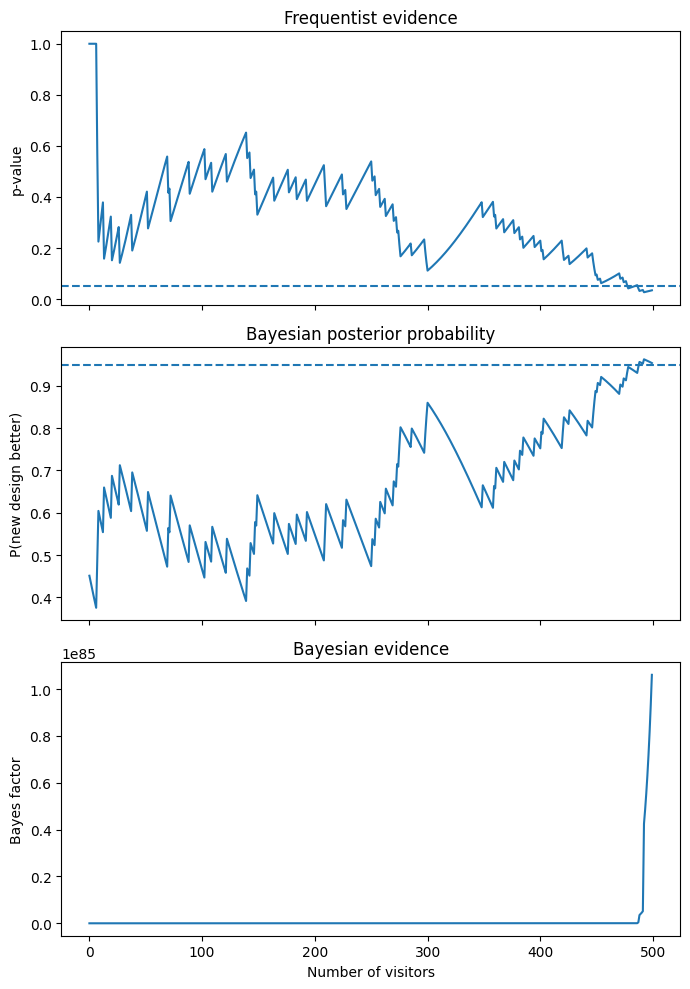

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(7,10), sharex=True)

# p-values
axes[0].plot(p_values)
axes[0].axhline(0.05, linestyle="--")
axes[0].set_ylabel("p-value")
axes[0].set_title("Frequentist evidence")

# posterior probability
axes[1].plot(p_better)
axes[1].axhline(0.95, linestyle="--")
axes[1].set_ylabel("P(new design better)")
axes[1].set_title("Bayesian posterior probability")

# Bayes factor
axes[2].plot(bayes_factors)
axes[2].set_ylabel("Bayes factor")
axes[2].set_xlabel("Number of visitors")
axes[2].set_title("Bayesian evidence")

plt.tight_layout()
plt.show()